# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.3.2
pandas version: 2.3.2
matplotlib version: 3.10.6
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [11]:
# Try loading one file
# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [12]:
# Sample the data
# It is recommended to not load all the files at once to avoid memory overload

In [13]:
import os
import glob

# Folder with the 12 parquet files
data_dir = 'Data'

files = sorted(glob.glob(os.path.join(data_dir, '*.parquet')))
print(f"Total files: {len(files)}")   # should be 12

# Sample 10% from each month and combine
sampled_dfs = []
for file in files:
    monthly_df = pd.read_parquet(file)
    sampled_dfs.append(monthly_df.sample(frac=0.1, random_state=42))
    print(f"Loaded: {os.path.basename(file)} — shape: {monthly_df.shape}")

df = pd.concat(sampled_dfs, ignore_index=True)
print(f"\nCombined shape: {df.shape}")

Total files: 12
Loaded: yellow_tripdata_2023-01.parquet — shape: (3066766, 19)
Loaded: yellow_tripdata_2023-02.parquet — shape: (2913955, 19)
Loaded: yellow_tripdata_2023-03.parquet — shape: (3403766, 19)
Loaded: yellow_tripdata_2023-04.parquet — shape: (3288250, 19)
Loaded: yellow_tripdata_2023-05.parquet — shape: (3513649, 19)
Loaded: yellow_tripdata_2023-06.parquet — shape: (3307234, 19)
Loaded: yellow_tripdata_2023-07.parquet — shape: (2907108, 19)
Loaded: yellow_tripdata_2023-08.parquet — shape: (2824209, 19)
Loaded: yellow_tripdata_2023-09.parquet — shape: (2846722, 19)
Loaded: yellow_tripdata_2023-10.parquet — shape: (3522285, 19)
Loaded: yellow_tripdata_2023-11.parquet — shape: (3339715, 19)
Loaded: yellow_tripdata_2023-12.parquet — shape: (3376567, 19)

Combined shape: (3831024, 20)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [14]:
# Store the df in csv/parquet
# df.to_parquet('nyc_taxi_2023_sampled.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [15]:
# Load the new data file
# df = pd.read_parquet('nyc_taxi_2023_sampled.parquet')

# For now, combined_df is our working dataframe
combined_df = df.copy()

In [16]:
combined_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0,NaN
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0,NaN
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0,NaN
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0,NaN
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0,NaN


In [17]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3831024 entries, 0 to 3831023
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [18]:
# Fix the index and drop any columns that are not needed
combined_df = combined_df.reset_index(drop=True)
print("Index fixed.")
print(combined_df.shape)

Index fixed.
(3831024, 20)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [19]:
# Check the duplicate airport fee columns
print(combined_df[['Airport_fee', 'airport_fee']].head(10))

# Merge airport fee columns
combined_df['Airport_fee'] = combined_df['Airport_fee'].fillna(combined_df['airport_fee'])

# Drop the duplicate
combined_df.drop(columns=['airport_fee'], inplace=True)

# Fix datetime columns
combined_df['tpep_pickup_datetime'] = pd.to_datetime(combined_df['tpep_pickup_datetime'])
combined_df['tpep_dropoff_datetime'] = pd.to_datetime(combined_df['tpep_dropoff_datetime'])

# Filter only 2023 data
combined_df = combined_df[
    (combined_df['tpep_pickup_datetime'].dt.year == 2023)
]

print(combined_df.shape)

   Airport_fee  airport_fee
0          NaN          0.0
1          NaN          0.0
2          NaN          0.0
3          NaN          0.0
4          NaN          0.0
5          NaN          0.0
6          NaN          0.0
7          NaN          0.0
8          NaN          0.0
9          NaN          0.0
(3831008, 19)


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [20]:
# Check where values of fare_amount are negative
neg_fare = combined_df[combined_df['fare_amount'] < 0]
print(f"Negative fare rows: {len(neg_fare)}")
print(neg_fare[['fare_amount', 'RatecodeID', 'trip_distance', 'total_amount']].head(10))

Negative fare rows: 38191
      fare_amount  RatecodeID  trip_distance  total_amount
102         -13.5         1.0           2.38         -17.5
300          -3.0         1.0           0.00          -9.5
340         -11.4         1.0           1.65         -16.4
369          -9.3         1.0           1.05         -13.3
672         -23.3         1.0           4.44         -27.3
786          -7.9         1.0           1.22         -11.9
787         -12.8         1.0           1.78         -16.8
1105        -17.0         1.0           1.78         -21.0
1113         -4.4         1.0           0.49          -8.4
1438        -17.0         1.0           3.04         -21.0


Did you notice something different in the `RatecodeID` column for above records?

In [21]:
# Analyse RatecodeID for the negative fare amounts
print(combined_df[combined_df['fare_amount'] < 0]['RatecodeID'].value_counts())

RatecodeID
1.0    33552
2.0     2650
5.0      696
3.0      425
4.0      201
Name: count, dtype: int64


In [22]:
# Find which columns have negative values
numeric_cols = combined_df.select_dtypes(include='number').columns
for col in numeric_cols:
    neg_count = (combined_df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")

fare_amount: 38191 negative values
extra: 19139 negative values
mta_tax: 36590 negative values
tip_amount: 192 negative values
tolls_amount: 2517 negative values
improvement_surcharge: 37697 negative values
total_amount: 37721 negative values
congestion_surcharge: 30291 negative values
Airport_fee: 5005 negative values


In [23]:
# Fix these negative values — take absolute values for monetary columns
monetary_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount',
                 'tolls_amount', 'improvement_surcharge', 'total_amount',
                 'congestion_surcharge', 'Airport_fee']

for col in monetary_cols:
    combined_df[col] = combined_df[col].abs()

print("Negative values fixed.")
combined_df[monetary_cols].describe()

Negative values fixed.


,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,3.831008e+06,3.831008e+06,3.831008e+06,3.831008e+06,3.831008e+06,3.831008e+06,3.831008e+06,3.700271e+06,3.700271e+06
mean,1.992100e+01,1.574340e+00,4.951836e-01,3.523689e+00,6.001678e-01,9.991155e-01,2.896236e+01,2.305348e+00,1.444449e-01
std,1.858766e+01,1.824605e+00,5.598313e-02,4.094892e+00,2.194769e+00,2.741536e-02,2.310451e+01,6.698801e-01,4.671332e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,1.350000e+01,1.000000e+00,5.000000e-01,2.800000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.250000e+01,2.500000e+00,5.000000e-01,4.410000e+00,0.000000e+00,1.000000e+00,3.100000e+01,2.500000e+00,0.000000e+00
max,2.194700e+03,1.650000e+01,5.316000e+01,7.000000e+02,1.707500e+02,1.000000e+00,2.203140e+03,2.500000e+00,1.750000e+00


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [24]:
# Find the proportion of missing values in each column
missing = pd.DataFrame({
    'Missing Count': combined_df.isnull().sum(),
    'Missing %': (combined_df.isnull().sum() / len(combined_df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])

                      Missing Count  Missing %
passenger_count              130737       3.41
RatecodeID                   130737       3.41
store_and_fwd_flag           130737       3.41
congestion_surcharge         130737       3.41
Airport_fee                  130737       3.41


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [25]:
# Display the rows with null values
print(f"Null passenger_count rows: {combined_df['passenger_count'].isnull().sum()}")
print("\nWhich vendor has missing passenger_count?")
print(combined_df[combined_df['passenger_count'].isnull()]['VendorID'].value_counts())

# Impute NaN values in 'passenger_count' with median
combined_df['passenger_count'].fillna(combined_df['passenger_count'].median(), inplace=True)

# Handle zeroes in passenger_count
zero_pax = (combined_df['passenger_count'] == 0).sum()
print(f"\nZero passenger_count rows: {zero_pax}")
combined_df['passenger_count'].replace(0, combined_df['passenger_count'].median(), inplace=True)

print("passenger_count nulls remaining:", combined_df['passenger_count'].isnull().sum())

Null passenger_count rows: 130737

Which vendor has missing passenger_count?
VendorID
2    79015
1    50854
6      868
Name: count, dtype: int64

Zero passenger_count rows: 58097
passenger_count nulls remaining: 0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [26]:
# Fix missing values in 'RatecodeID'
print(f"Null RatecodeID rows: {combined_df['RatecodeID'].isnull().sum()}")
combined_df['RatecodeID'].fillna(combined_df['RatecodeID'].mode()[0], inplace=True)
print("RatecodeID nulls remaining:", combined_df['RatecodeID'].isnull().sum())

Null RatecodeID rows: 130737
RatecodeID nulls remaining: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [27]:
# Handle null values in congestion_surcharge
print(f"Null congestion_surcharge rows: {combined_df['congestion_surcharge'].isnull().sum()}")
combined_df['congestion_surcharge'].fillna(combined_df['congestion_surcharge'].median(), inplace=True)
print("congestion_surcharge nulls remaining:", combined_df['congestion_surcharge'].isnull().sum())

Null congestion_surcharge rows: 130737
congestion_surcharge nulls remaining: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [28]:
# Handle any remaining missing values
combined_df['store_and_fwd_flag'].fillna(combined_df['store_and_fwd_flag'].mode()[0], inplace=True)
combined_df['Airport_fee'].fillna(0, inplace=True)

# Verify no missing values remain
print("Total remaining nulls:", combined_df.isnull().sum().sum())  # should print 0
print(combined_df.isnull().sum())

Total remaining nulls: 0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [29]:
# Describe the data and check if there are any potential outliers present
cols = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'passenger_count']
combined_df[cols].describe()

,fare_amount,trip_distance,tip_amount,total_amount,passenger_count
count,3.831008e+06,3.831008e+06,3.831008e+06,3.831008e+06,3.831008e+06
mean,1.992100e+01,3.967518e+00,3.523689e+00,2.896236e+01,1.372969e+00
std,1.858766e+01,1.933530e+02,4.094892e+00,2.310451e+01,8.656230e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.300000e+00,1.040000e+00,1.000000e+00,1.596000e+01,1.000000e+00
50%,1.350000e+01,1.790000e+00,2.800000e+00,2.100000e+01,1.000000e+00
75%,2.250000e+01,3.400000e+00,4.410000e+00,3.100000e+01,1.000000e+00
max,2.194700e+03,2.055442e+05,7.000000e+02,2.203140e+03,9.000000e+00


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [30]:
# Remove passenger_count > 6
before = len(combined_df)
combined_df = combined_df[combined_df['passenger_count'] <= 6]
print(f"Removed {before - len(combined_df)} rows with passenger_count > 6")
print(f"Remaining rows: {len(combined_df)}")

Removed 30 rows with passenger_count > 6
Remaining rows: 3830978


In [31]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Lower={lower:.2f}, Upper={upper:.2f}, Outliers={len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

for col in ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount']:
    detect_outliers_iqr(combined_df, col)

# Payment type valid values: 1,2,3,4,5,6
print("\nPayment type outliers:", len(combined_df[~combined_df['payment_type'].isin([1,2,3,4,5,6])]))

# Drop payment_type 0
combined_df = combined_df[combined_df['payment_type'].isin([1,2,3,4,5,6])]

# Remove entries where trip_distance is nearly 0 but fare > 300
combined_df = combined_df[~((combined_df['trip_distance'] < 0.1) & (combined_df['fare_amount'] > 300))]

# Remove entries where both trip_distance and fare_amount are 0 but zones differ
combined_df = combined_df[~(
    (combined_df['trip_distance'] == 0) &
    (combined_df['fare_amount'] == 0) &
    (combined_df['PULocationID'] != combined_df['DOLocationID'])
)]

# Remove entries where trip_distance > 250
combined_df = combined_df[combined_df['trip_distance'] <= 250]

print(f"\nFinal shape after outlier removal: {combined_df.shape}")

fare_amount: Lower=-10.50, Upper=42.30, Outliers=382359 (9.98%)
trip_distance: Lower=-2.50, Upper=6.94, Outliers=506300 (13.22%)
tip_amount: Lower=-4.12, Upper=9.53, Outliers=294268 (7.68%)
total_amount: Lower=-6.60, Upper=53.56, Outliers=443422 (11.57%)

Payment type outliers: 130737

Final shape after outlier removal: (3699977, 19)


In [32]:
# Standardise column names to lowercase
combined_df.columns = [col.lower() for col in combined_df.columns]
print("Columns after standardising:", combined_df.columns.tolist())

Columns after standardising: ['vendorid', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'store_and_fwd_flag', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [33]:
combined_df.columns.tolist()

['vendorid',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecodeid',
 'store_and_fwd_flag',
 'pulocationid',
 'dolocationid',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

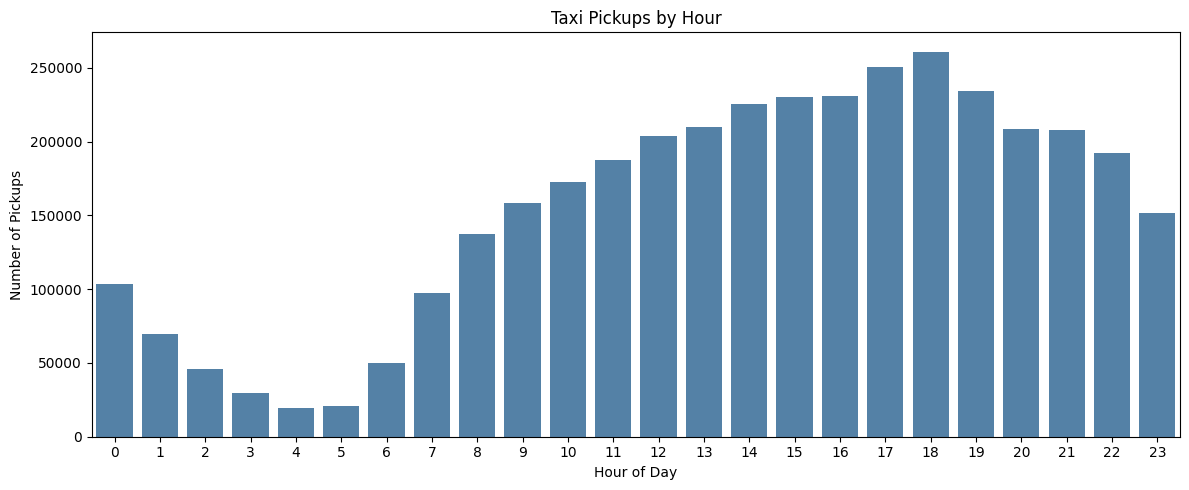

In [34]:
# Extract time features
combined_df['hour'] = combined_df['tpep_pickup_datetime'].dt.hour
combined_df['day_of_week'] = combined_df['tpep_pickup_datetime'].dt.day_name()
combined_df['month'] = combined_df['tpep_pickup_datetime'].dt.month

# Hourly distribution
plt.figure(figsize=(12, 5))
sns.countplot(x='hour', data=combined_df, color='steelblue')
plt.title('Taxi Pickups by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.tight_layout()
plt.show()

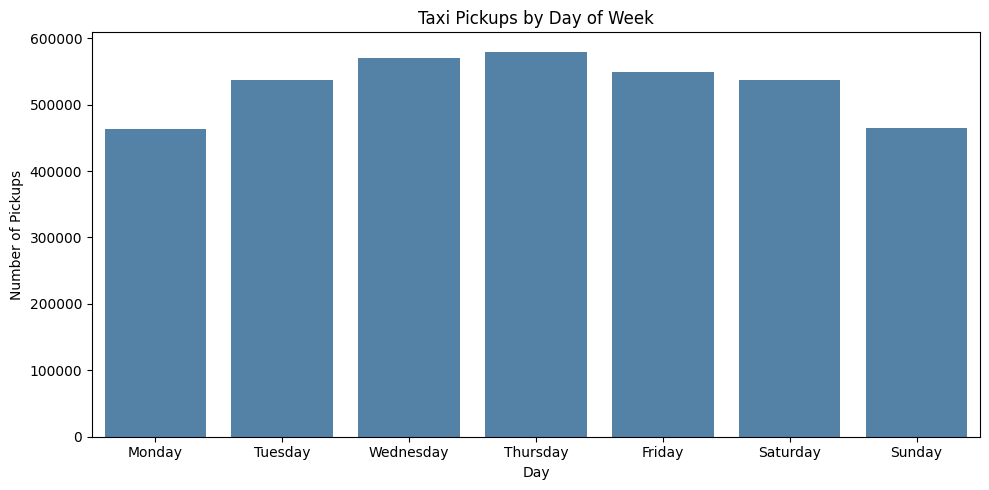

In [35]:
# Daily distribution
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(x='day_of_week', data=combined_df, order=day_order, color='steelblue')
plt.title('Taxi Pickups by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Pickups')
plt.tight_layout()
plt.show()

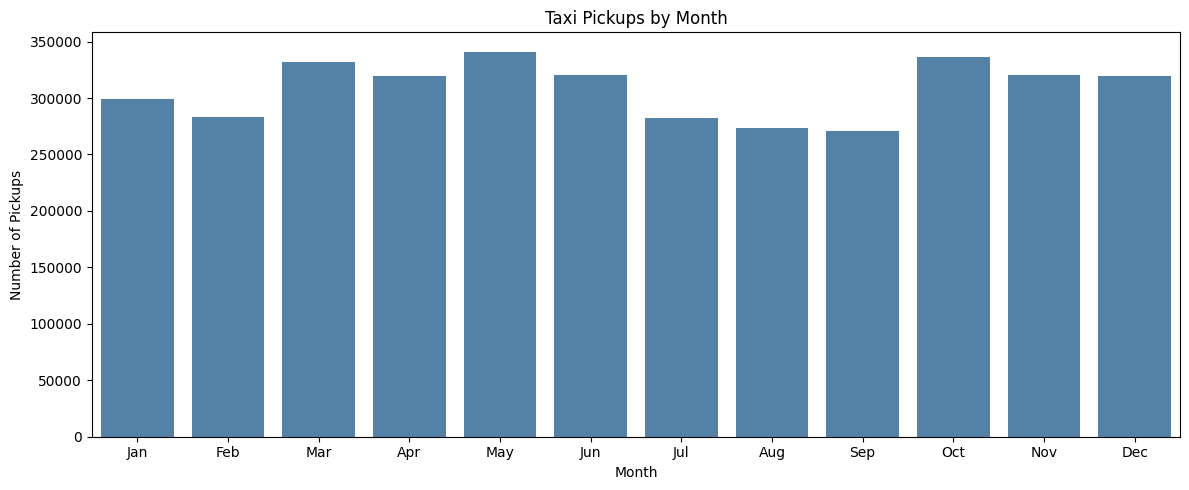

In [36]:
# Monthly distribution
plt.figure(figsize=(12, 5))
sns.countplot(x='month', data=combined_df, color='steelblue')
plt.title('Taxi Pickups by Month')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [37]:
# Analyse financial parameters
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
print(combined_df[cols].describe())

# Check for zero/negative values
for col in cols:
    zeros = (combined_df[col] == 0).sum()
    negs = (combined_df[col] < 0).sum()
    print(f"{col}: zeros={zeros}, negatives={negs}")

        fare_amount    tip_amount  total_amount  trip_distance
count  3.699977e+06  3.699977e+06  3.699977e+06   3.699977e+06
mean   1.982231e+01  3.550140e+00  2.892530e+01   3.456569e+00
std    1.854065e+01  4.111429e+00  2.313210e+01   4.585604e+00
min    0.000000e+00  0.000000e+00  0.000000e+00   0.000000e+00
25%    9.300000e+00  1.000000e+00  1.596000e+01   1.050000e+00
50%    1.350000e+01  2.800000e+00  2.100000e+01   1.780000e+00
75%    2.190000e+01  4.420000e+00  3.072000e+01   3.380000e+00
max    2.194700e+03  7.000000e+02  2.203140e+03   2.496300e+02
fare_amount: zeros=1134, negatives=0
tip_amount: zeros=854820, negatives=0
total_amount: zeros=490, negatives=0
trip_distance: zeros=47920, negatives=0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [38]:
# Create a df with non-zero entries for the selected parameters
df_clean = combined_df[
    (combined_df['fare_amount'] > 0) &
    (combined_df['trip_distance'] > 0) &
    (combined_df['tip_amount'] >= 0)
].copy()

print(f"Rows before filtering: {len(combined_df)}")
print(f"Rows after filtering: {len(df_clean)}")
print(f"Rows removed: {len(combined_df) - len(df_clean)}")

Rows before filtering: 3699977
Rows after filtering: 3651438
Rows removed: 48539


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

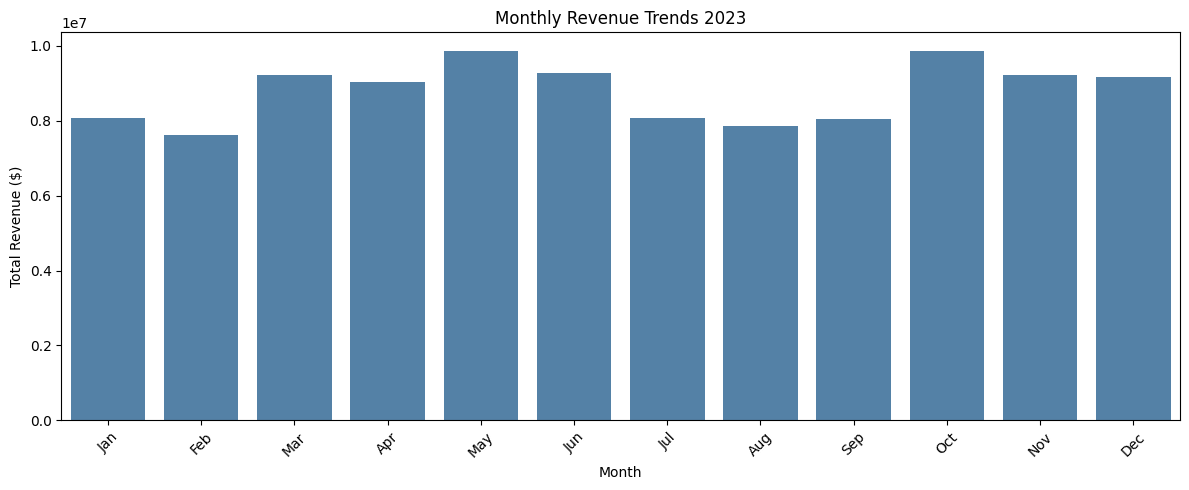

   month_name     revenue
0         Jan  8064053.35
1         Feb  7629410.61
2         Mar  9214030.42
3         Apr  9034471.50
4         May  9868216.47
5         Jun  9287637.01
6         Jul  8063797.88
7         Aug  7869209.27
8         Sep  8046477.85
9         Oct  9856592.46
10        Nov  9217992.24
11        Dec  9161194.05


In [39]:
# Group data by month and analyse monthly revenue
monthly_revenue = df_clean.groupby('month')['total_amount'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_revenue['month_name'] = monthly_revenue['month'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(12, 5))
sns.barplot(x='month_name', y='revenue', data=monthly_revenue, color='steelblue')
plt.title('Monthly Revenue Trends 2023')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly_revenue[['month_name', 'revenue']])

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

  quarter      revenue  revenue_%
0      Q1  24907494.38      23.65
1      Q2  28190324.98      26.77
2      Q3  23979485.00      22.77
3      Q4  28235778.75      26.81


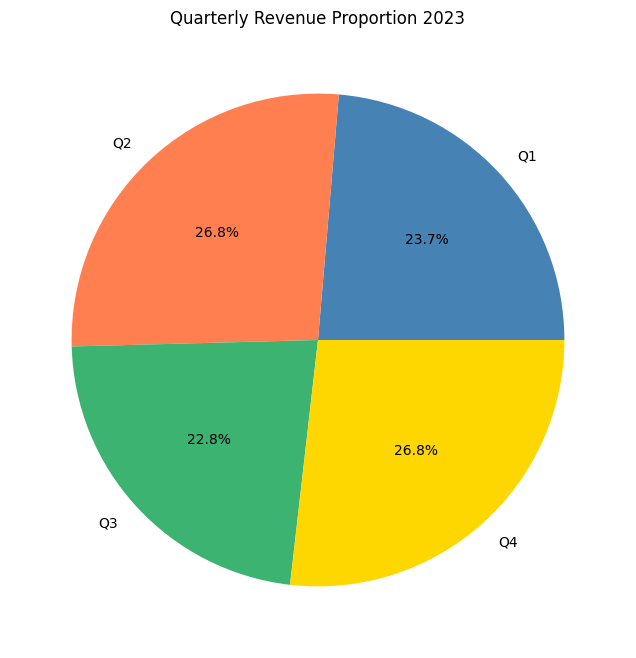

In [40]:
# Add quarter column
df_clean['quarter'] = df_clean['tpep_pickup_datetime'].dt.quarter

# Quarterly revenue
quarterly_revenue = df_clean.groupby('quarter')['total_amount'].sum().reset_index()
quarterly_revenue.columns = ['quarter', 'revenue']
quarterly_revenue['revenue_%'] = (quarterly_revenue['revenue'] / quarterly_revenue['revenue'].sum() * 100).round(2)
quarterly_revenue['quarter'] = 'Q' + quarterly_revenue['quarter'].astype(str)

print(quarterly_revenue)

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(quarterly_revenue['revenue'],
        labels=quarterly_revenue['quarter'],
        autopct='%1.1f%%',
        colors=['steelblue','coral','mediumseagreen','gold'])
plt.title('Quarterly Revenue Proportion 2023')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between distance and fare: 0.9474


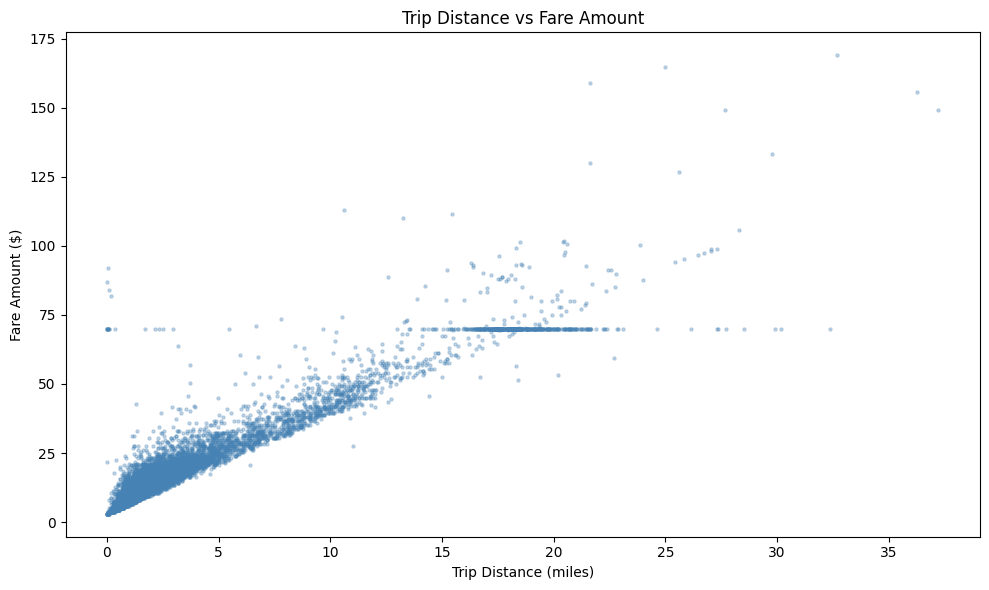

In [41]:
# Show how trip fare is affected by distance
df_dist_fare = df_clean[
    (df_clean['trip_distance'] < 50) &
    (df_clean['fare_amount'] < 200)
]

corr = df_dist_fare['trip_distance'].corr(df_dist_fare['fare_amount'])
print(f"Correlation between distance and fare: {corr:.4f}")

sample = df_dist_fare.sample(n=min(10000, len(df_dist_fare)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['trip_distance'], sample['fare_amount'],
            alpha=0.3, color='steelblue', s=5)
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between trip duration and fare: 0.8440


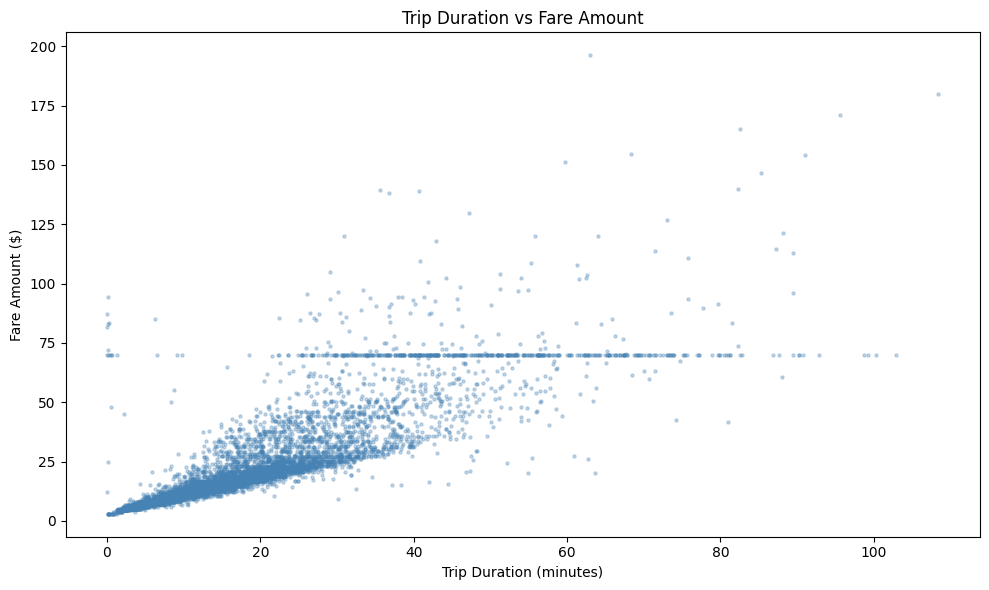

In [42]:
# Show relationship between fare and trip duration
df_clean['trip_duration'] = (df_clean['tpep_dropoff_datetime'] -
                              df_clean['tpep_pickup_datetime']).dt.total_seconds() / 60

df_dur = df_clean[(df_clean['trip_duration'] > 0) & (df_clean['trip_duration'] < 120)]

corr_dur = df_dur['trip_duration'].corr(df_dur['fare_amount'])
print(f"Correlation between trip duration and fare: {corr_dur:.4f}")

sample_dur = df_dur.sample(n=min(10000, len(df_dur)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_dur['trip_duration'], sample_dur['fare_amount'],
            alpha=0.3, color='steelblue', s=5)
plt.title('Trip Duration vs Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

Correlation between passenger count and fare: 0.0430


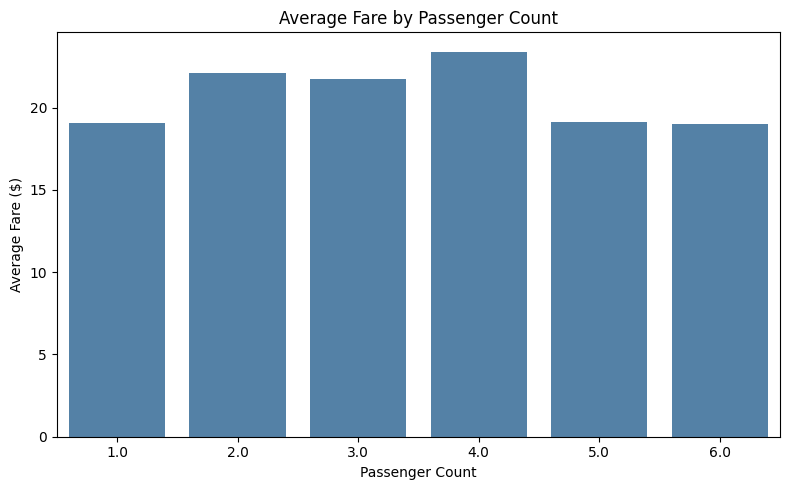

In [43]:
# Show relationship between fare and number of passengers
avg_fare_pax = df_clean.groupby('passenger_count')['fare_amount'].mean().reset_index()

corr_pax = df_clean['passenger_count'].corr(df_clean['fare_amount'])
print(f"Correlation between passenger count and fare: {corr_pax:.4f}")

plt.figure(figsize=(8, 5))
sns.barplot(x='passenger_count', y='fare_amount', data=avg_fare_pax, color='steelblue')
plt.title('Average Fare by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare ($)')
plt.tight_layout()
plt.show()

Correlation between trip distance and tip: 0.5976


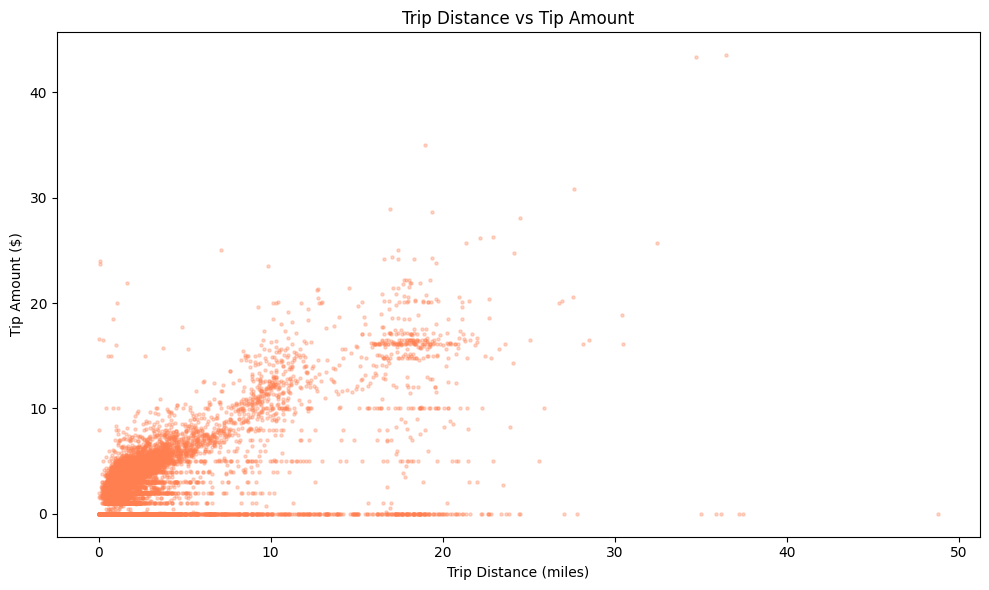

In [44]:
# Show relationship between tip and trip distance
df_tip_dist = df_clean[(df_clean['trip_distance'] < 50) & (df_clean['tip_amount'] < 50)]

corr_tip = df_tip_dist['trip_distance'].corr(df_tip_dist['tip_amount'])
print(f"Correlation between trip distance and tip: {corr_tip:.4f}")

sample_tip = df_tip_dist.sample(n=min(10000, len(df_tip_dist)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_tip['trip_distance'], sample_tip['tip_amount'],
            alpha=0.3, color='coral', s=5)
plt.title('Trip Distance vs Tip Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.tight_layout()
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

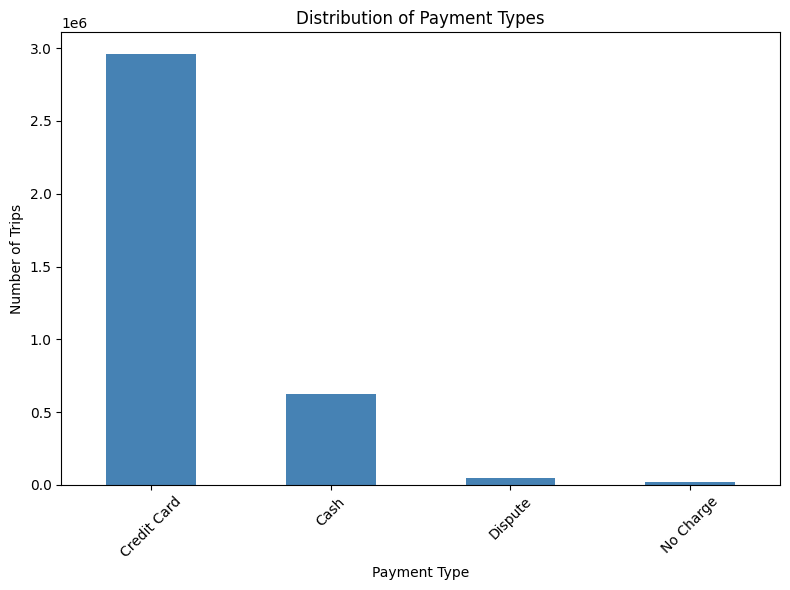

payment_label
Credit Card    81.08
Cash           17.19
Dispute         1.24
No Charge       0.49
Name: proportion, dtype: float64


In [45]:
# Analyse the distribution of different payment types
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
df_clean['payment_label'] = df_clean['payment_type'].map(payment_map)

plt.figure(figsize=(8, 6))
df_clean['payment_label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_clean['payment_label'].value_counts(normalize=True).mul(100).round(2))

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [46]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [48]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('shapefile/taxi_zones.shp')
print(zones.shape)
zones.head()

(263, 7)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


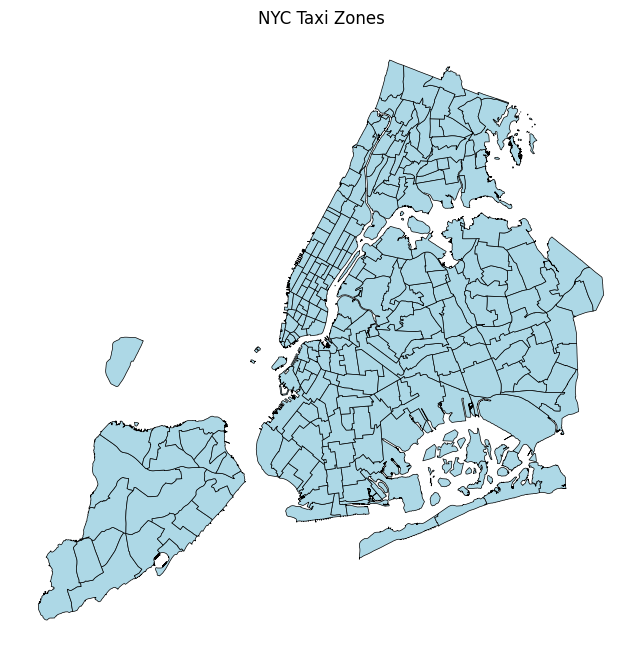

In [49]:
print(zones.info())
zones.plot(figsize=(10, 8), color='lightblue', edgecolor='black', linewidth=0.5)
plt.title('NYC Taxi Zones')
plt.axis('off')
plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
df_merged = df_clean.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='pulocationid',
    right_on='LocationID',
    how='left'
)
df_merged.rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'}, inplace=True)
print(df_merged.shape)
df_merged[['pulocationid', 'pickup_zone', 'pickup_borough']].head()

(3651438, 28)


,pulocationid,pickup_zone,pickup_borough
0,141,Lenox Hill West,Manhattan
1,138,LaGuardia Airport,Queens
2,138,LaGuardia Airport,Queens
3,234,Union Sq,Manhattan
4,137,Kips Bay,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trips_per_zone = df_clean['pulocationid'].value_counts().reset_index()
trips_per_zone.columns = ['LocationID', 'trip_count']
print(trips_per_zone.head(10))

   LocationID  trip_count
0         132      194629
1         237      174868
2         161      172261
3         236      154429
4         162      132371
5         138      128485
6         186      127631
7         230      123538
8         142      121309
9         170      109502


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trips_per_zone, on='LocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
print(zones_with_trips[['zone', 'trip_count']].sort_values('trip_count', ascending=False).head(10))

                             zone  trip_count
131                   JFK Airport    194629.0
236         Upper East Side South    174868.0
160                Midtown Center    172261.0
235         Upper East Side North    154429.0
161                  Midtown East    132371.0
137             LaGuardia Airport    128485.0
185  Penn Station/Madison Sq West    127631.0
229     Times Sq/Theatre District    123538.0
141           Lincoln Square East    121309.0
169                   Murray Hill    109502.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

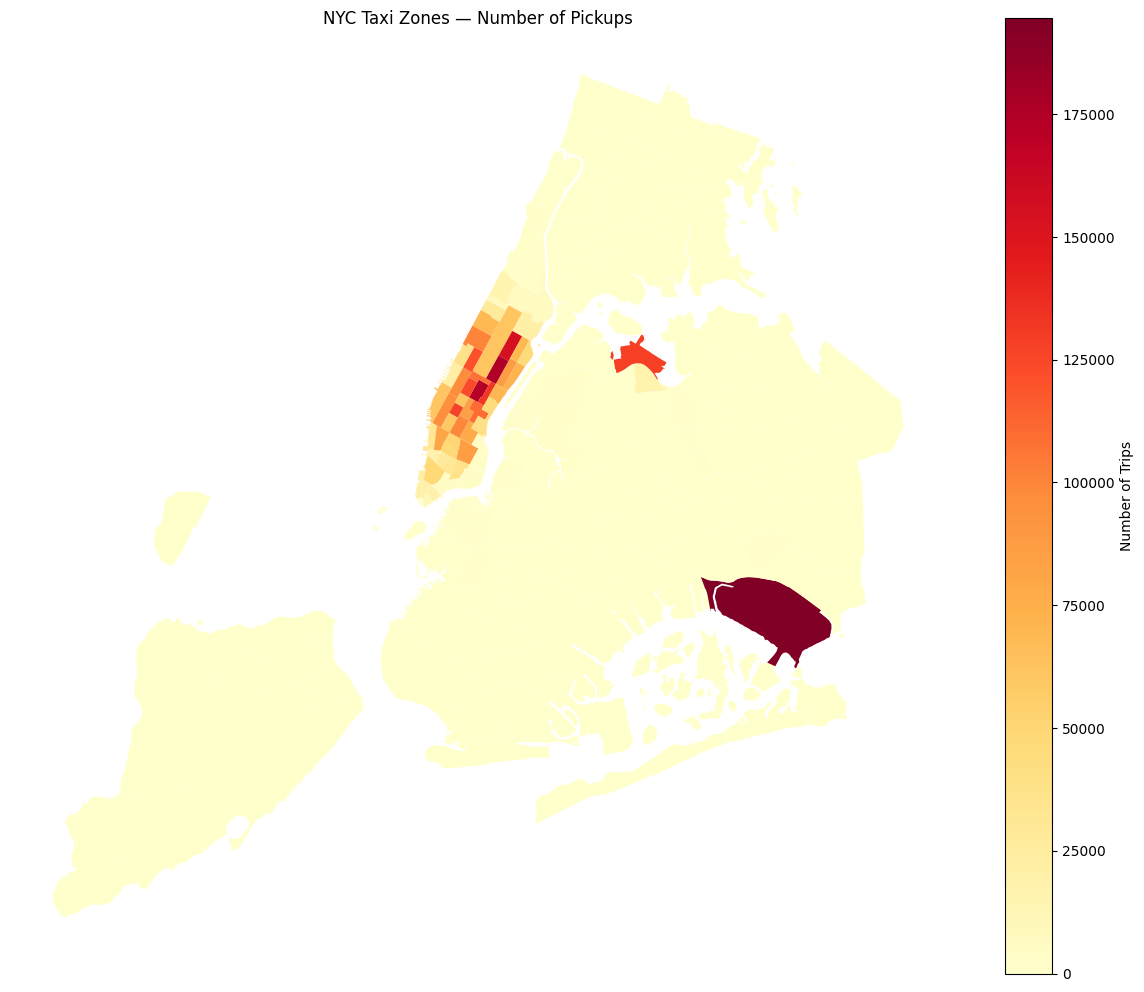

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': "Number of Trips", 'orientation': "vertical"}
)
plt.title('NYC Taxi Zones — Number of Pickups')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Display zones DF sorted by number of trips
zones_with_trips[['zone', 'borough', 'trip_count']].sort_values('trip_count', ascending=False).head(20)

,zone,borough,trip_count
131,JFK Airport,Queens,194629.0
236,Upper East Side South,Manhattan,174868.0
160,Midtown Center,Manhattan,172261.0
235,Upper East Side North,Manhattan,154429.0
161,Midtown East,Manhattan,132371.0
137,LaGuardia Airport,Queens,128485.0
185,Penn Station/Madison Sq West,Manhattan,127631.0
229,Times Sq/Theatre District,Manhattan,123538.0
141,Lincoln Square East,Manhattan,121309.0
169,Murray Hill,Manhattan,109502.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Calculate trip duration if not already done
if 'trip_duration' not in df_clean.columns:
    df_clean['trip_duration'] = (df_clean['tpep_dropoff_datetime'] -
                                  df_clean['tpep_pickup_datetime']).dt.total_seconds() / 60

# Calculate average speed (miles per hour)
df_clean['speed'] = df_clean['trip_distance'] / (df_clean['trip_duration'] / 60)

# Filter unrealistic speeds
df_speed = df_clean[
    (df_clean['speed'] > 0) &
    (df_clean['speed'] < 80) &
    (df_clean['trip_duration'] > 0)
].copy()

# Find slow routes (PU -> DO pairs)
routes = df_speed.groupby(['pulocationid', 'dolocationid']).agg(
    avg_speed=('speed', 'mean'),
    trip_count=('speed', 'count')
).reset_index()

# Filter routes with enough trips
routes = routes[routes['trip_count'] >= 50]

# Merge zone names
routes = routes.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID')
routes = routes.rename(columns={'zone': 'pickup_zone'}).drop('LocationID', axis=1)
routes = routes.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID')
routes = routes.rename(columns={'zone': 'dropoff_zone'}).drop('LocationID', axis=1)

# Top 10 slowest routes
print("Top 10 Slowest Routes:")
print(routes.nsmallest(10, 'avg_speed')[['pickup_zone', 'dropoff_zone', 'avg_speed', 'trip_count']])

Top 10 Slowest Routes:
                       pickup_zone               dropoff_zone  avg_speed  \
2461                Midtown Center  Times Sq/Theatre District   5.059422   
2894  Penn Station/Madison Sq West           Garment District   5.239583   
2545                  Midtown East  Times Sq/Theatre District   5.264966   
3260     Times Sq/Theatre District  Times Sq/Theatre District   5.368365   
2528                  Midtown East             Midtown Center   5.492730   
3443           UN/Turtle Bay South  Times Sq/Theatre District   5.545873   
2920  Penn Station/Madison Sq West              Midtown South   5.584949   
981               Garment District           Garment District   5.608149   
2800                   Murray Hill           Garment District   5.653528   
3410           UN/Turtle Bay South           Garment District   5.724435   

      trip_count  
2461        5278  
2894        2266  
2545        4239  
3260        3934  
2528        4795  
3443        1394  
2920   

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

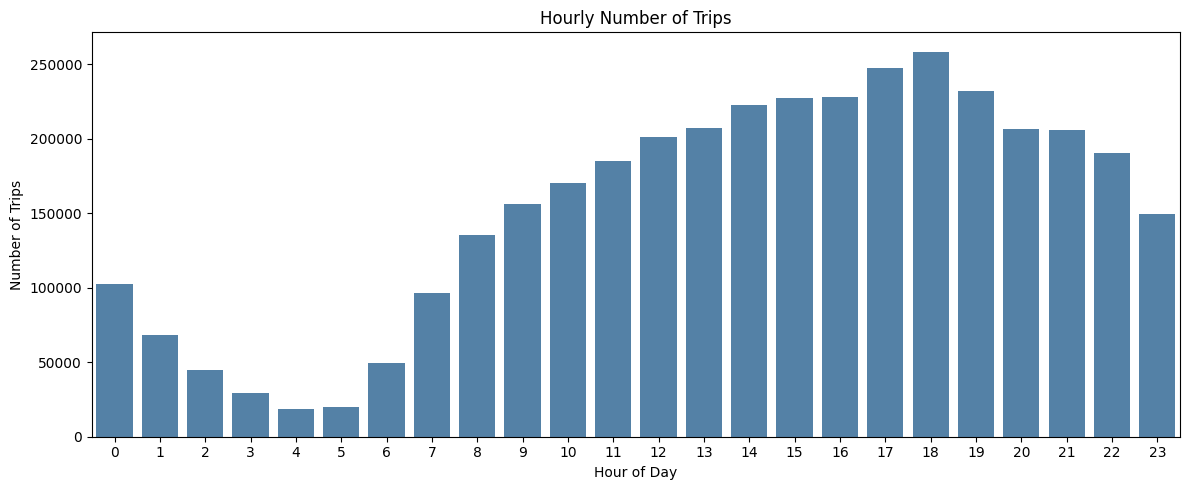

Busiest hour: 18:00
    hour  trip_count
18    18      258352
17    17      247298
19    19      231863
16    16      227958
15    15      227344


In [ ]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trips = df_clean.groupby('hour').size().reset_index(name='trip_count')

plt.figure(figsize=(12, 5))
sns.barplot(x='hour', y='trip_count', data=hourly_trips, color='steelblue')
plt.title('Hourly Number of Trips')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()

busiest_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax(), 'hour']
print(f"Busiest hour: {busiest_hour}:00")
print(hourly_trips.sort_values('trip_count', ascending=False).head())

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips
# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.1  # we sampled 10% of data

hourly_trips['actual_trip_count'] = hourly_trips['trip_count'] / sample_fraction

# Top 5 busiest hours (actual count)
print("Top 5 Busiest Hours (Actual Trips Estimated):")
print(hourly_trips.nlargest(5, 'actual_trip_count')[['hour', 'actual_trip_count']])

Top 5 Busiest Hours (Actual Trips Estimated):
    hour  actual_trip_count
18    18          2583520.0
17    17          2472980.0
19    19          2318630.0
16    16          2279580.0
15    15          2273440.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

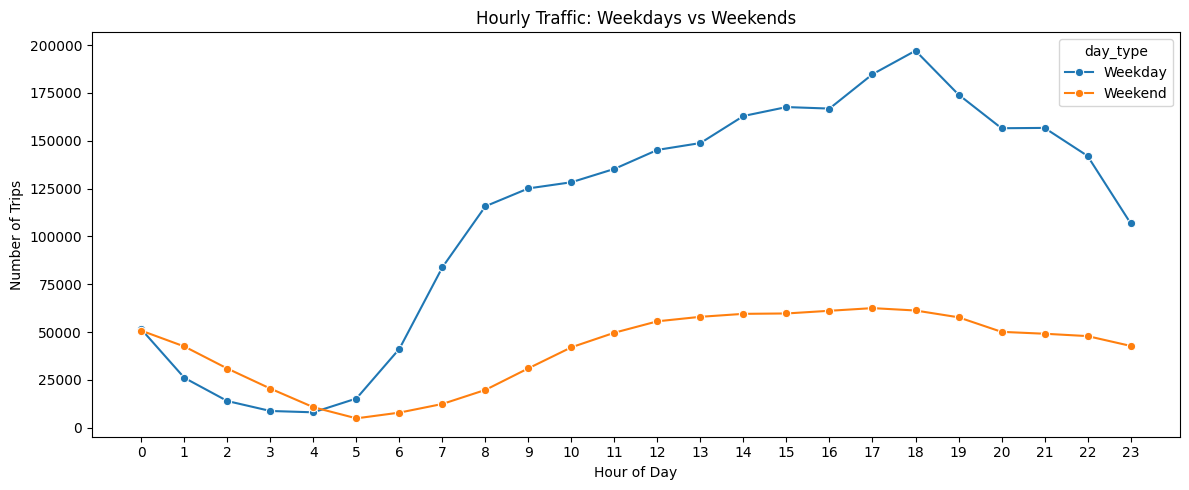

In [ ]:
# Compare traffic trends for the week days and weekends
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Sunday'])

hourly_week = df_clean.groupby(['hour', 'is_weekend']).size().reset_index(name='trip_count')
hourly_week['day_type'] = hourly_week['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

plt.figure(figsize=(12, 5))
sns.lineplot(x='hour', y='trip_count', hue='day_type', data=hourly_week, marker='o')
plt.title('Hourly Traffic: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

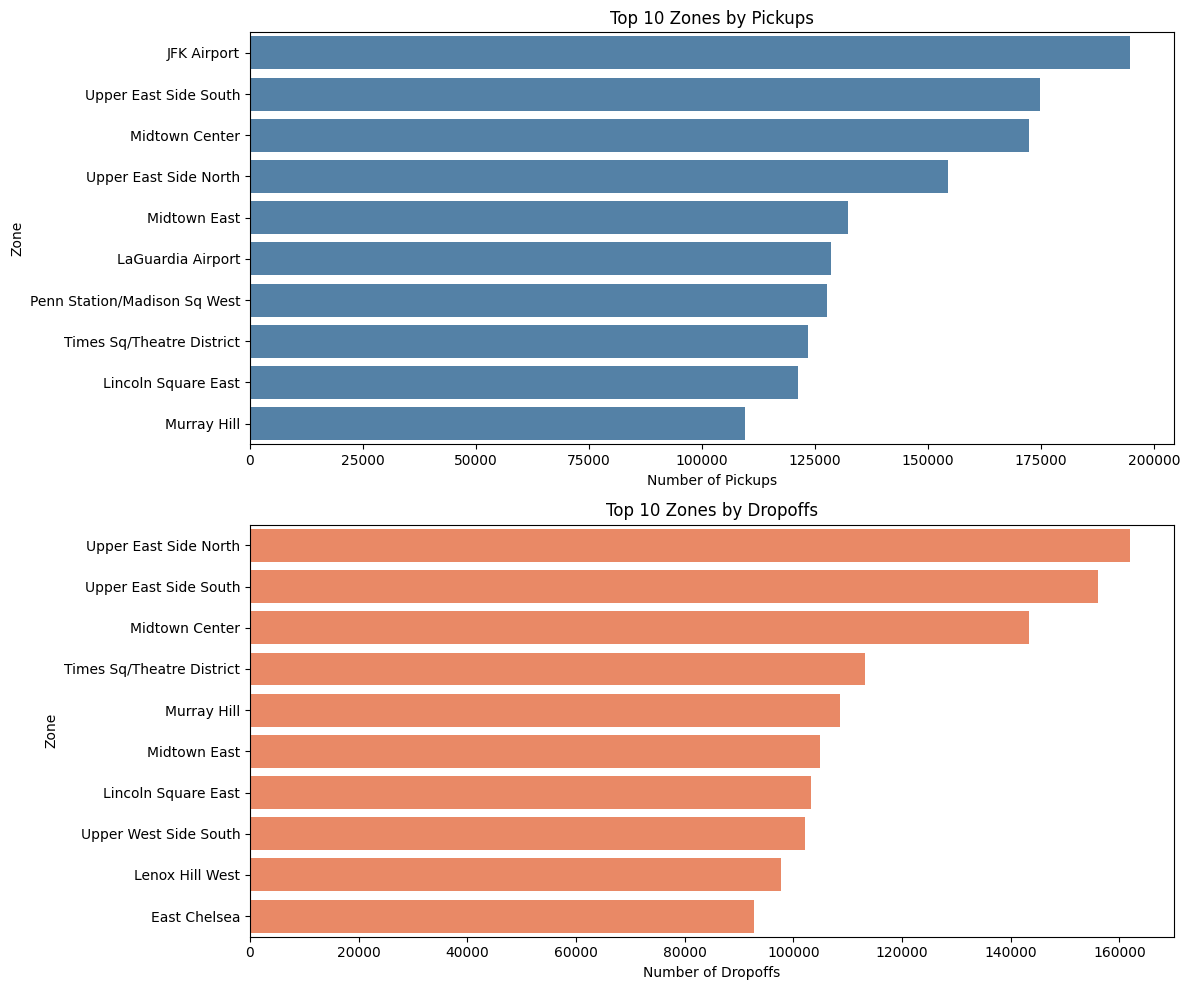

In [ ]:
# Find top 10 pickup and dropoff zones
top_pickup = df_clean.groupby('pulocationid').size().reset_index(name='pickup_count')
top_pickup = top_pickup.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID')
top_pickup = top_pickup.nlargest(10, 'pickup_count')

top_dropoff = df_clean.groupby('dolocationid').size().reset_index(name='dropoff_count')
top_dropoff = top_dropoff.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID')
top_dropoff = top_dropoff.nlargest(10, 'dropoff_count')

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.barplot(x='pickup_count', y='zone', data=top_pickup, ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Zones by Pickups')
axes[0].set_xlabel('Number of Pickups')
axes[0].set_ylabel('Zone')

sns.barplot(x='dropoff_count', y='zone', data=top_dropoff, ax=axes[1], color='coral')
axes[1].set_title('Top 10 Zones by Dropoffs')
axes[1].set_xlabel('Number of Dropoffs')
axes[1].set_ylabel('Zone')

plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

Top 10 zones — highest pickup/dropoff ratio:
                                              zone  pickups  dropoffs  \
69                                   East Elmhurst    16765      1969   
128                                    JFK Airport   194629     40770   
134                              LaGuardia Airport   128485     44122   
102  Governor's Island/Ellis Island/Liberty Island        2         1   
181                   Penn Station/Madison Sq West   127631     80189   
110                        Greenwich Village South    49131     34966   
42                                    Central Park    61504     45105   
241                                   West Village    81711     61037   
158                                   Midtown East   132371    104902   
157                                 Midtown Center   172261    143396   

        ratio  
69   8.514474  
128  4.773829  
134  2.912039  
102  2.000000  
181  1.591627  
110  1.405108  
42   1.363574  
241  1.338713  
158  1.

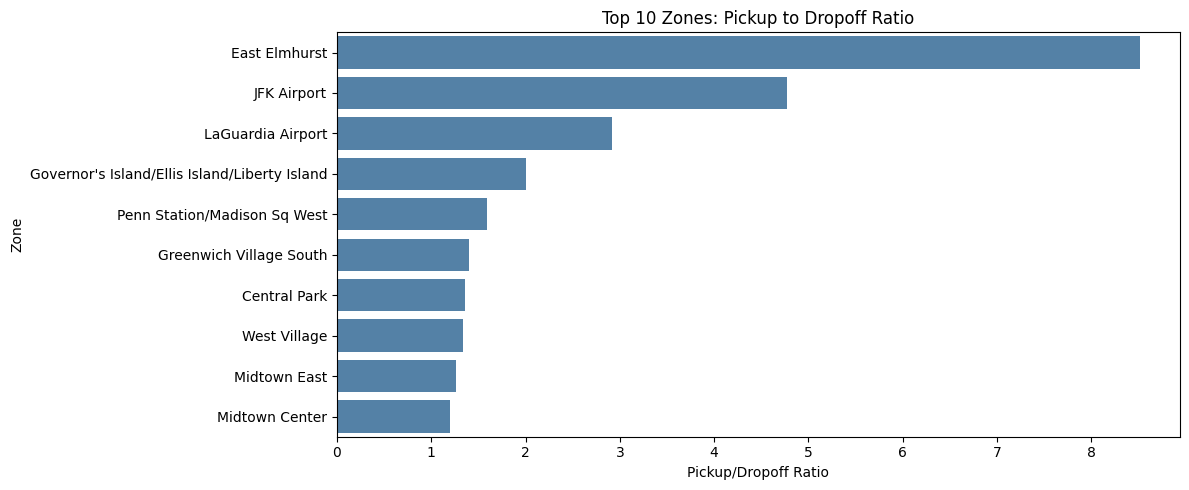

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df_clean.groupby('pulocationid').size().reset_index(name='pickups')
dropoff_counts = df_clean.groupby('dolocationid').size().reset_index(name='dropoffs')

zone_traffic = pickup_counts.merge(dropoff_counts, left_on='pulocationid', right_on='dolocationid')
zone_traffic['ratio'] = zone_traffic['pickups'] / zone_traffic['dropoffs']
zone_traffic = zone_traffic.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID')

top_ratio = zone_traffic.nlargest(10, 'ratio')[['zone', 'pickups', 'dropoffs', 'ratio']]
bot_ratio = zone_traffic.nsmallest(10, 'ratio')[['zone', 'pickups', 'dropoffs', 'ratio']]

print("Top 10 zones — highest pickup/dropoff ratio:")
print(top_ratio)
print("\nBottom 10 zones — lowest pickup/dropoff ratio:")
print(bot_ratio)

plt.figure(figsize=(12, 5))
sns.barplot(x='ratio', y='zone', data=top_ratio, color='steelblue')
plt.title('Top 10 Zones: Pickup to Dropoff Ratio')
plt.xlabel('Pickup/Dropoff Ratio')
plt.ylabel('Zone')
plt.tight_layout()
plt.show()

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

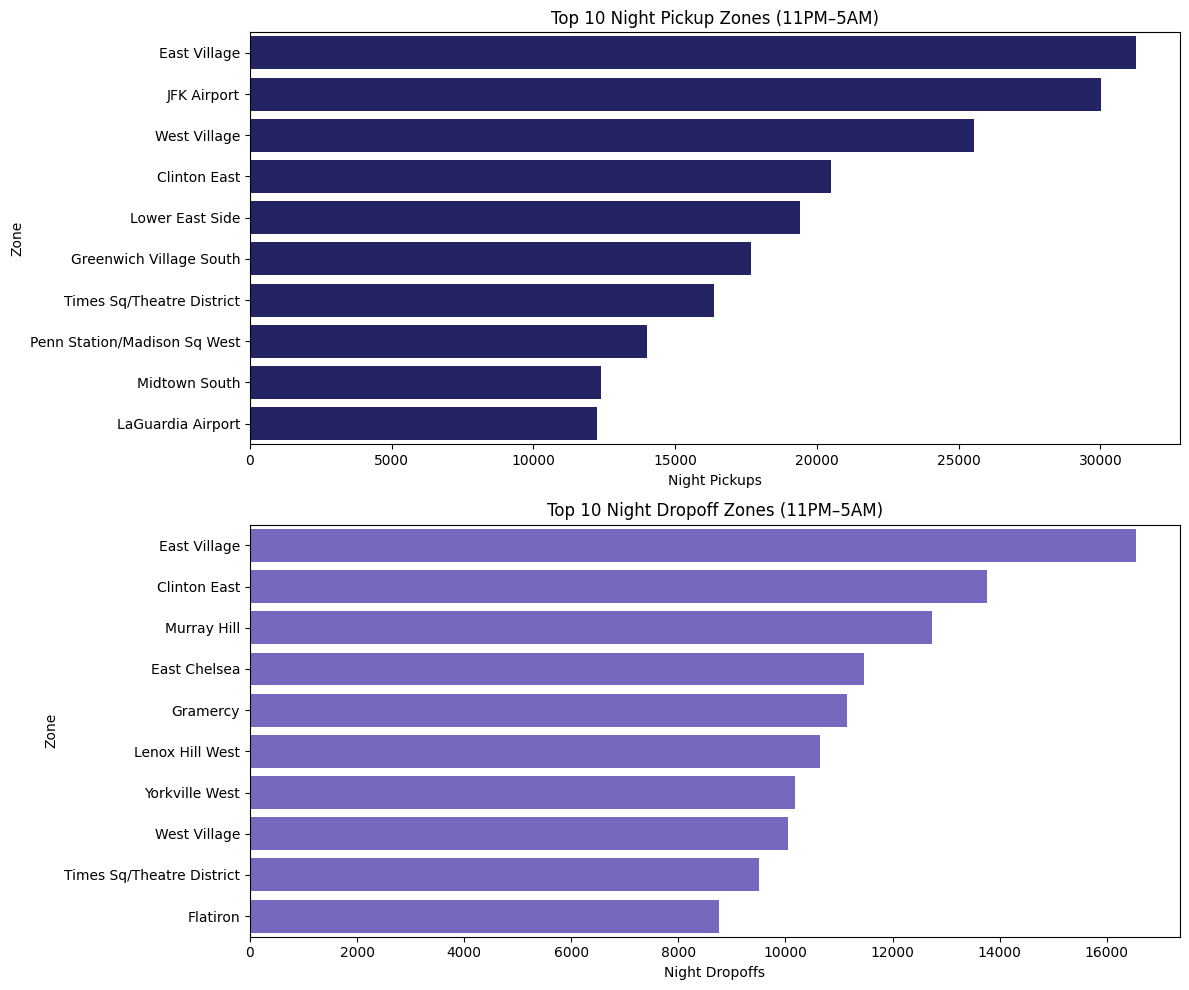

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
night_df = df_clean[df_clean['hour'].isin([23, 0, 1, 2, 3, 4, 5])]

night_pickups = night_df.groupby('pulocationid').size().reset_index(name='night_pickups')
night_pickups = night_pickups.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID')
top_night = night_pickups.nlargest(10, 'night_pickups')

night_dropoffs = night_df.groupby('dolocationid').size().reset_index(name='night_dropoffs')
night_dropoffs = night_dropoffs.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID')
top_night_drop = night_dropoffs.nlargest(10, 'night_dropoffs')

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.barplot(x='night_pickups', y='zone', data=top_night, ax=axes[0], color='midnightblue')
axes[0].set_title('Top 10 Night Pickup Zones (11PM–5AM)')
axes[0].set_xlabel('Night Pickups')
axes[0].set_ylabel('Zone')

sns.barplot(x='night_dropoffs', y='zone', data=top_night_drop, ax=axes[1], color='slateblue')
axes[1].set_title('Top 10 Night Dropoff Zones (11PM–5AM)')
axes[1].set_xlabel('Night Dropoffs')
axes[1].set_ylabel('Zone')

plt.tight_layout()
plt.show()

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

  time_of_day  total_amount  revenue_%
0         Day   92546720.58      87.88
1       Night   12766362.53      12.12


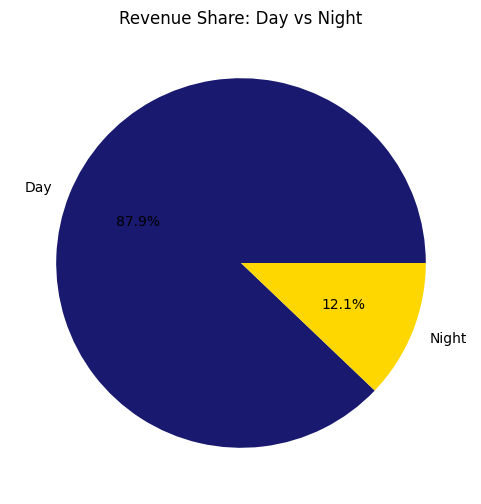

In [ ]:
# Filter for night hours (11 PM to 5 AM)
df_clean['time_of_day'] = df_clean['hour'].apply(
    lambda x: 'Night' if x in [23, 0, 1, 2, 3, 4, 5] else 'Day'
)

revenue_split = df_clean.groupby('time_of_day')['total_amount'].sum().reset_index()
revenue_split['revenue_%'] = (revenue_split['total_amount'] /
                               revenue_split['total_amount'].sum() * 100).round(2)

print(revenue_split)

plt.figure(figsize=(6, 6))
plt.pie(revenue_split['total_amount'],
        labels=revenue_split['time_of_day'],
        autopct='%1.1f%%',
        colors=['midnightblue', 'gold'])
plt.title('Revenue Share: Day vs Night')
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

   passenger_count  fare_per_mile_per_pax
0              1.0               7.915700
1              2.0               3.851998
2              3.0               2.613953
3              4.0               1.955148
4              5.0               1.535671
5              6.0               1.307190


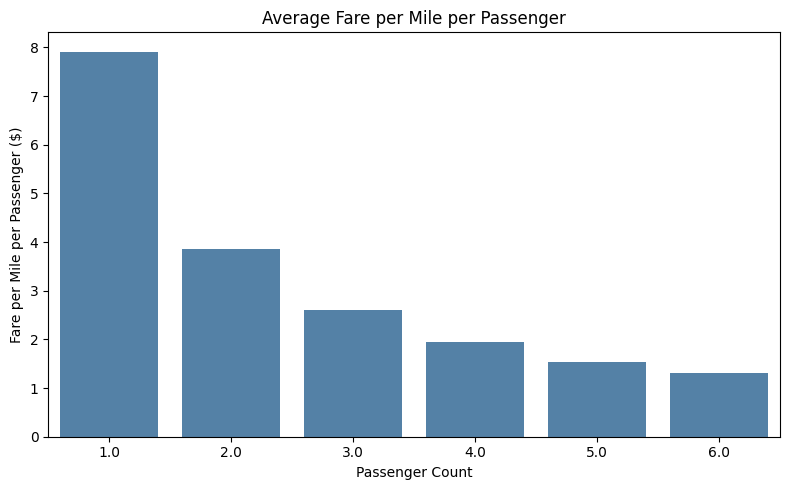

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts
df_clean['fare_per_mile'] = df_clean['fare_amount'] / df_clean['trip_distance']

df_fpm = df_clean[
    (df_clean['fare_per_mile'] > 0) &
    (df_clean['fare_per_mile'] < 100) &
    (df_clean['passenger_count'] > 0) &
    (df_clean['passenger_count'] <= 6)
].copy()

df_fpm['fare_per_mile_per_pax'] = df_fpm['fare_per_mile'] / df_fpm['passenger_count']
avg_fpm = df_fpm.groupby('passenger_count')['fare_per_mile_per_pax'].mean().reset_index()

print(avg_fpm)

plt.figure(figsize=(8, 5))
sns.barplot(x='passenger_count', y='fare_per_mile_per_pax', data=avg_fpm, color='steelblue')
plt.title('Average Fare per Mile per Passenger')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger ($)')
plt.tight_layout()
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

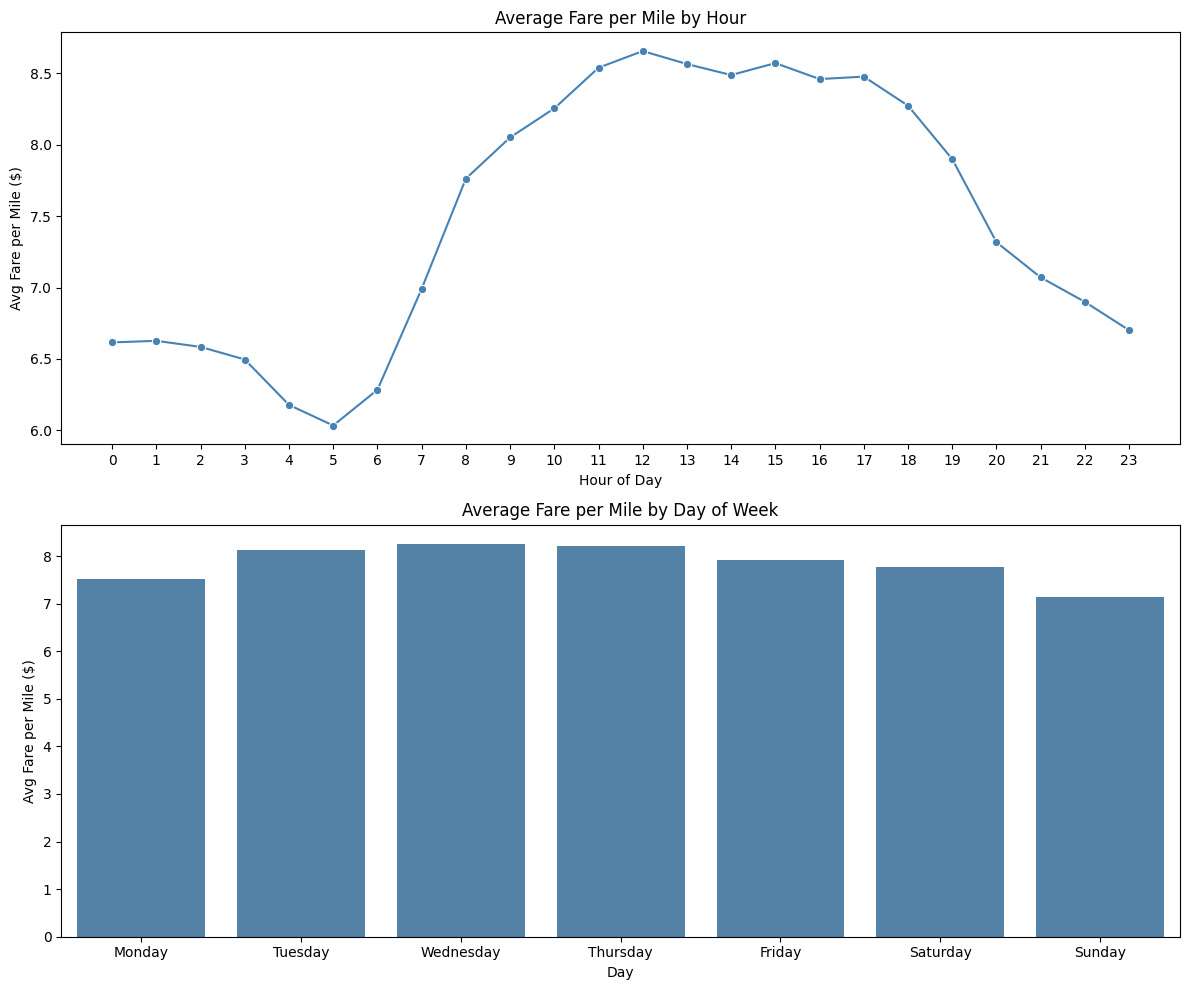

In [ ]:
# Compare the average fare per mile for different days and for different times of the day
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

hourly_fpm = df_fpm.groupby('hour')['fare_per_mile'].mean().reset_index()
sns.lineplot(x='hour', y='fare_per_mile', data=hourly_fpm, ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Average Fare per Mile by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Fare per Mile ($)')
axes[0].set_xticks(range(24))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_fpm = df_fpm.groupby('day_of_week')['fare_per_mile'].mean().reset_index()
sns.barplot(x='day_of_week', y='fare_per_mile', data=daily_fpm,
            order=day_order, ax=axes[1], color='steelblue')
axes[1].set_title('Average Fare per Mile by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Fare per Mile ($)')

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

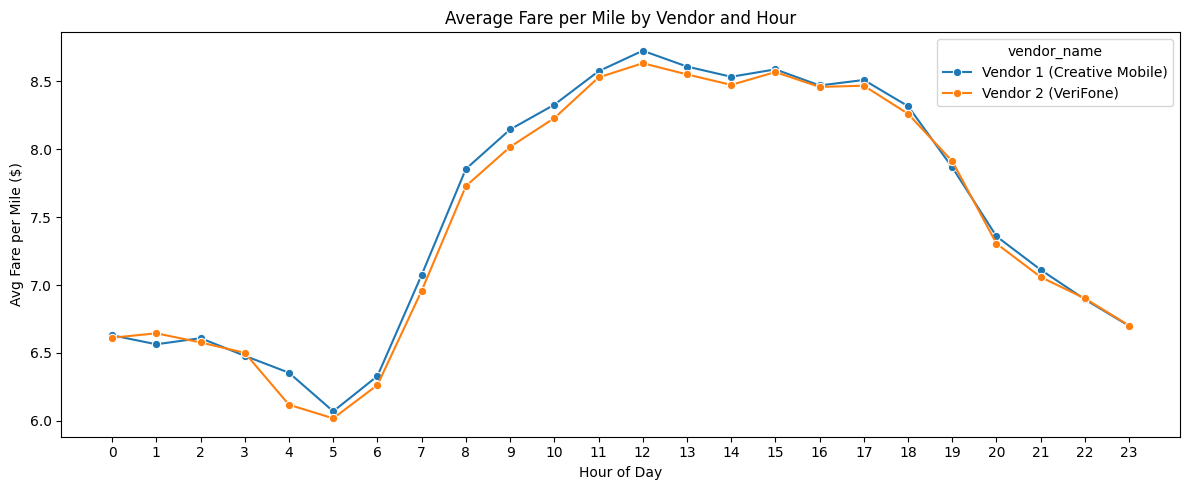

In [ ]:
# Compare fare per mile for different vendors
vendor_map = {1: 'Vendor 1 (Creative Mobile)', 2: 'Vendor 2 (VeriFone)'}
df_fpm['vendor_name'] = df_fpm['vendorid'].map(vendor_map).fillna('Other')

vendor_fpm = df_fpm.groupby(['vendor_name', 'hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x='hour', y='fare_per_mile', hue='vendor_name', data=vendor_fpm, marker='o')
plt.title('Average Fare per Mile by Vendor and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Fare per Mile ($)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


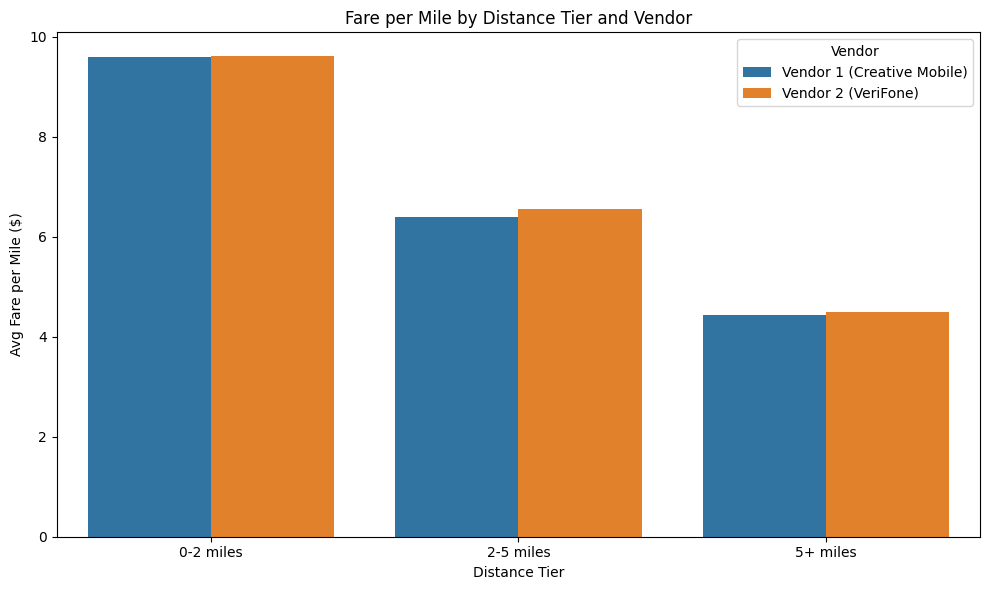

In [ ]:
# Defining distance tiers
df_fpm['distance_tier'] = pd.cut(df_fpm['trip_distance'],
                                  bins=[0, 2, 5, 100],
                                  labels=['0-2 miles', '2-5 miles', '5+ miles'])

vendor_tier = df_fpm.groupby(['distance_tier', 'vendor_name'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='distance_tier', y='fare_per_mile', hue='vendor_name', data=vendor_tier)
plt.title('Fare per Mile by Distance Tier and Vendor')
plt.xlabel('Distance Tier')
plt.ylabel('Avg Fare per Mile ($)')
plt.legend(title='Vendor')
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

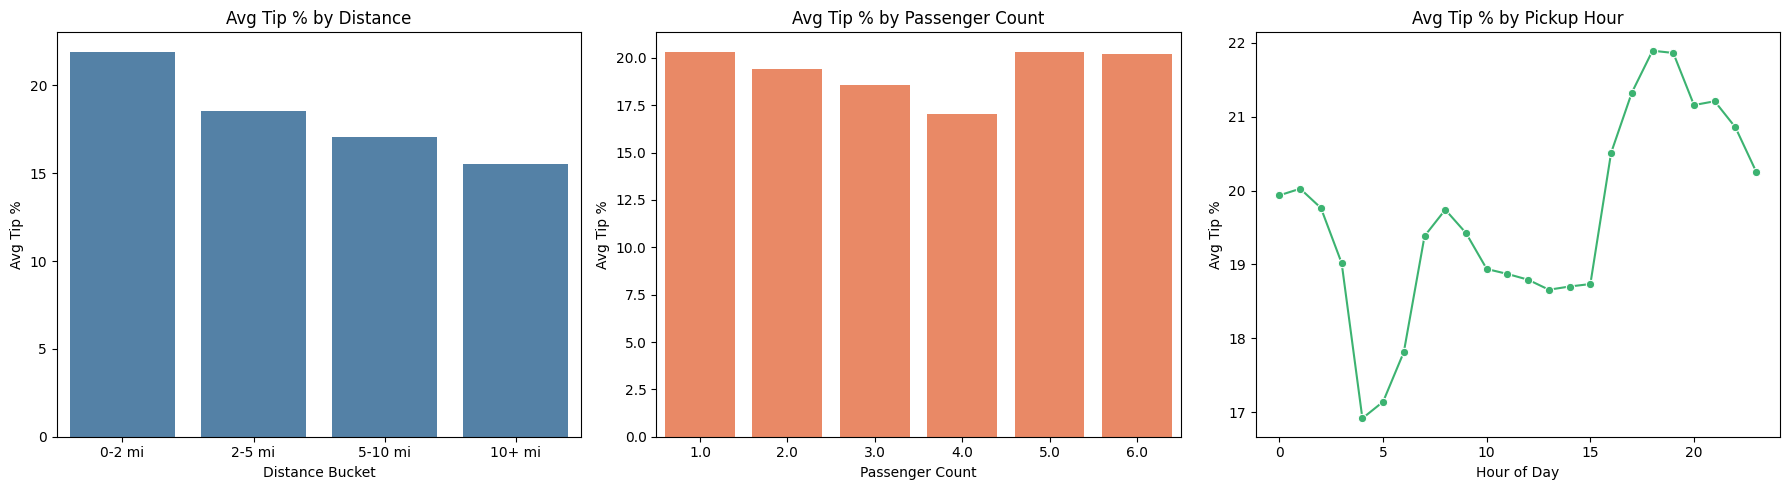

In [50]:
# Analyze tip percentages based on distances, passenger counts and pickup times
df_clean['tip_percentage'] = (df_clean['tip_amount'] / df_clean['fare_amount'] * 100)

df_tip = df_clean[
    (df_clean['tip_percentage'] >= 0) &
    (df_clean['tip_percentage'] <= 100)
].copy()

# Average tip % by distance bucket
df_tip['dist_bucket'] = pd.cut(df_tip['trip_distance'], bins=[0, 2, 5, 10, 50],
                                labels=['0-2 mi', '2-5 mi', '5-10 mi', '10+ mi'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By distance
tip_dist = df_tip.groupby('dist_bucket')['tip_percentage'].mean().reset_index()
sns.barplot(x='dist_bucket', y='tip_percentage', data=tip_dist, ax=axes[0], color='steelblue')
axes[0].set_title('Avg Tip % by Distance')
axes[0].set_xlabel('Distance Bucket')
axes[0].set_ylabel('Avg Tip %')

# By passenger count
tip_pax = df_tip.groupby('passenger_count')['tip_percentage'].mean().reset_index()
sns.barplot(x='passenger_count', y='tip_percentage', data=tip_pax, ax=axes[1], color='coral')
axes[1].set_title('Avg Tip % by Passenger Count')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Avg Tip %')

# By hour
tip_hour = df_tip.groupby('hour')['tip_percentage'].mean().reset_index()
sns.lineplot(x='hour', y='tip_percentage', data=tip_hour, ax=axes[2], marker='o', color='mediumseagreen')
axes[2].set_title('Avg Tip % by Pickup Hour')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Tip %')

plt.tight_layout()
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [51]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip = df_tip[df_tip['tip_percentage'] < 10]
high_tip = df_tip[df_tip['tip_percentage'] > 25]

print(f"Low tip trips (<10%): {len(low_tip)}")
print(f"High tip trips (>25%): {len(high_tip)}")

comparison = pd.DataFrame({
    'Low Tip (<10%)': low_tip[['trip_distance','fare_amount','passenger_count','hour']].mean(),
    'High Tip (>25%)': high_tip[['trip_distance','fare_amount','passenger_count','hour']].mean()
})
print("\nComparison of avg metrics:")
print(comparison)

Low tip trips (<10%): 974717
High tip trips (>25%): 1621687

Comparison of avg metrics:
                 Low Tip (<10%)  High Tip (>25%)
trip_distance          3.922794         2.302891
fare_amount           21.630655        14.429029
passenger_count        1.431530         1.363907
hour                  13.927634        14.617434


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

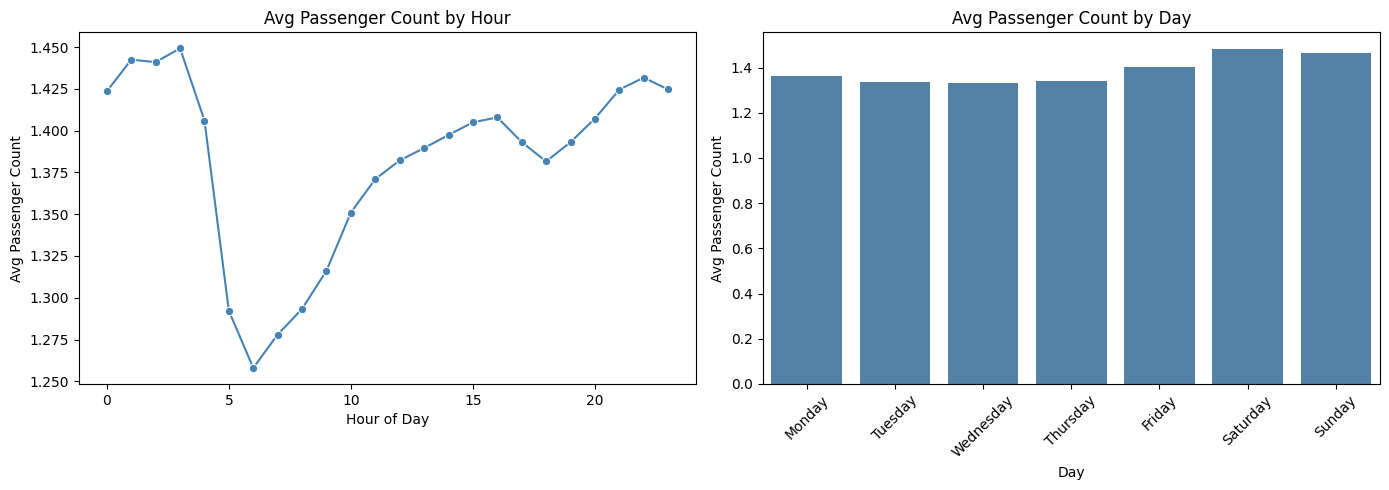

In [52]:
# See how passenger count varies across hours and days
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_pax = df_clean.groupby('hour')['passenger_count'].mean().reset_index()
sns.lineplot(x='hour', y='passenger_count', data=hourly_pax, marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Passenger Count by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Passenger Count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_pax = df_clean.groupby('day_of_week')['passenger_count'].mean().reset_index()
sns.barplot(x='day_of_week', y='passenger_count', data=daily_pax,
            order=day_order, ax=axes[1], color='steelblue')
axes[1].set_title('Avg Passenger Count by Day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Passenger Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

                             zone  avg_passenger_count
107           Green-Wood Cemetery             2.000000
111           Grymes Hill/Clifton             2.000000
5         Arrochar/Fort Wadsworth             1.974359
11                   Battery Park             1.813073
189                      Red Hook             1.757493
0                  Newark Airport             1.693548
65             DUMBO/Vinegar Hill             1.619978
92   Flushing Meadows-Corona Park             1.577206
254            World Trade Center             1.546845
44                      Chinatown             1.529652


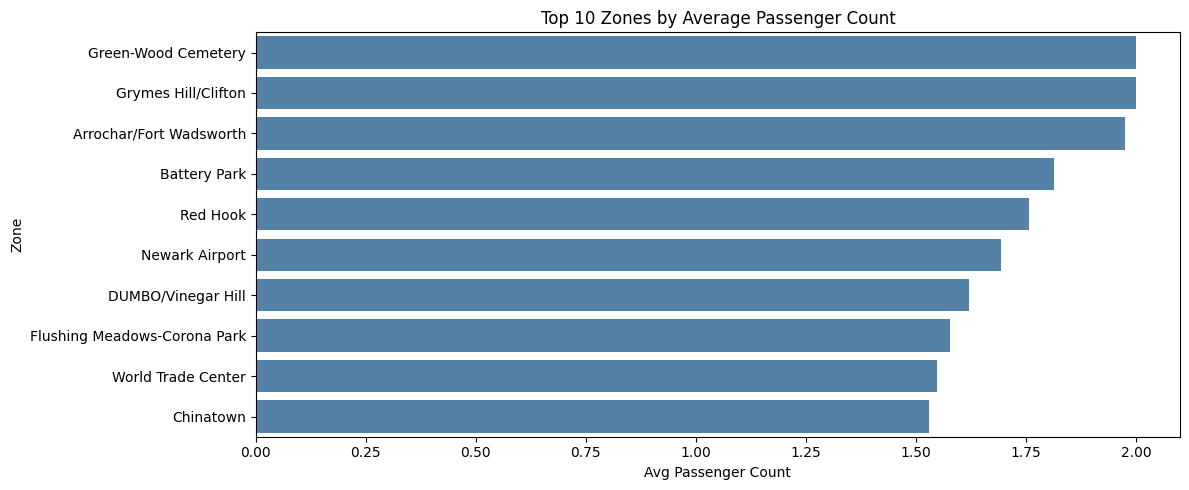

In [53]:
# How does passenger count vary across zones
zone_pax = df_clean.groupby('pulocationid')['passenger_count'].mean().reset_index()
zone_pax.columns = ['LocationID', 'avg_passenger_count']
zone_pax = zone_pax.merge(zones[['LocationID', 'zone']], on='LocationID')

top_pax = zone_pax.nlargest(10, 'avg_passenger_count')
print(top_pax[['zone', 'avg_passenger_count']])

plt.figure(figsize=(12, 5))
sns.barplot(x='avg_passenger_count', y='zone', data=top_pax, color='steelblue')
plt.title('Top 10 Zones by Average Passenger Count')
plt.xlabel('Avg Passenger Count')
plt.ylabel('Zone')
plt.tight_layout()
plt.show()

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone
zone_pax_geo = zones_with_trips.merge(
    zone_pax[['LocationID', 'avg_passenger_count']], on='LocationID', how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zone_pax_geo.plot(column='avg_passenger_count', ax=ax, legend=True,
                   cmap='Blues',
                   legend_kwds={'label': 'Avg Passenger Count', 'orientation': 'vertical'},
                   edgecolor='black', linewidth=0.3)
plt.title('Average Passenger Count by Zone')
plt.axis('off')
plt.tight_layout()
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

extra: applied in 61.9% of trips
mta_tax: applied in 99.4% of trips
improvement_surcharge: applied in 100.0% of trips
congestion_surcharge: applied in 92.8% of trips
airport_fee: applied in 8.9% of trips


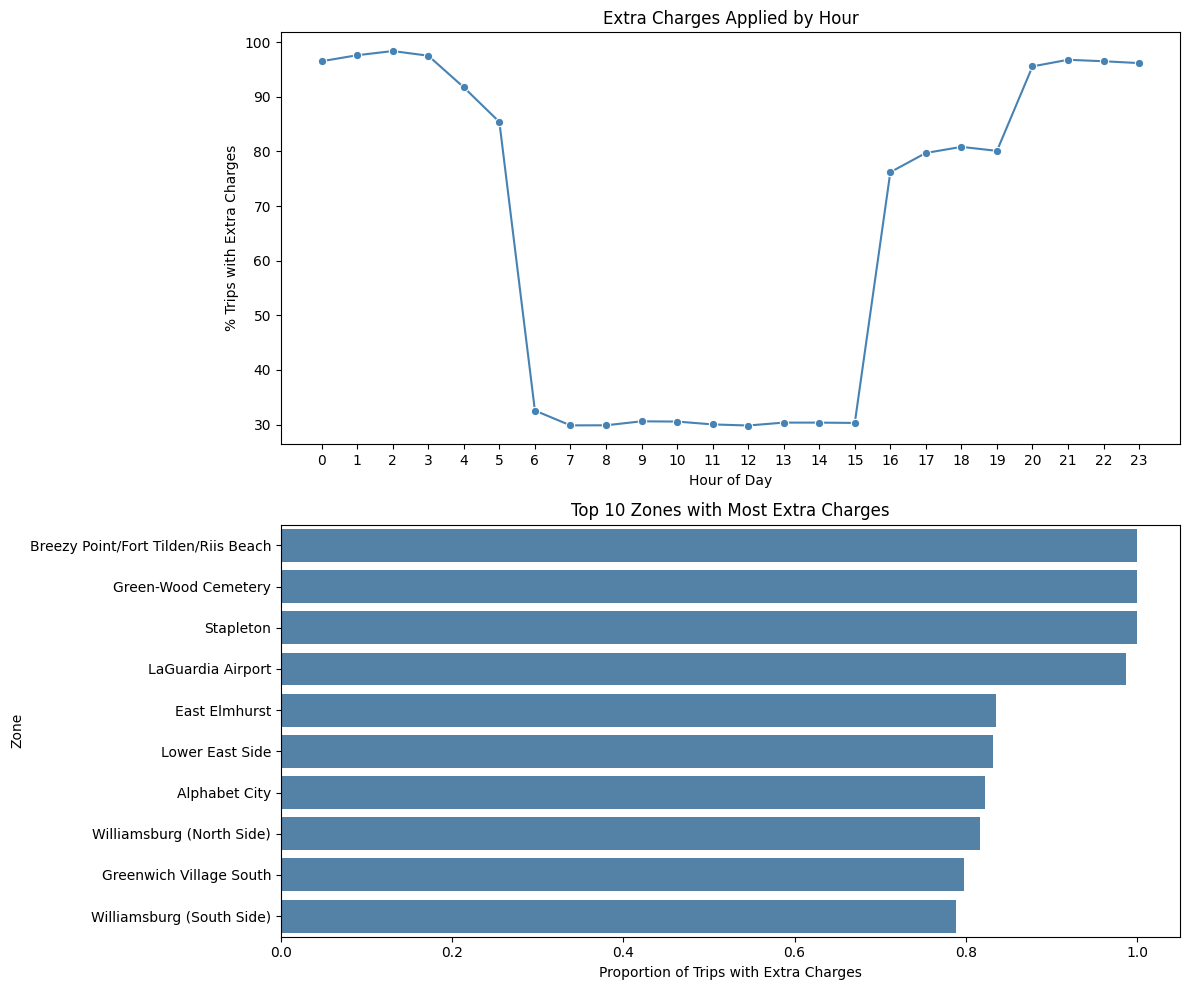

In [54]:
# How often is each surcharge applied?
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

for col in surcharge_cols:
    if col in df_clean.columns:
        pct = (df_clean[col] > 0).mean() * 100
        print(f"{col}: applied in {pct:.1f}% of trips")

# By hour
df_clean['has_extra'] = df_clean['extra'] > 0
extra_by_hour = df_clean.groupby('hour')['has_extra'].mean().reset_index()
extra_by_hour['extra_%'] = extra_by_hour['has_extra'] * 100

# By zone
extra_by_zone = df_clean.groupby('pulocationid')['has_extra'].mean().reset_index()
extra_by_zone = extra_by_zone.merge(zones[['LocationID', 'zone']],
                                     left_on='pulocationid', right_on='LocationID')
top_extra_zones = extra_by_zone.nlargest(10, 'has_extra')

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.lineplot(x='hour', y='extra_%', data=extra_by_hour, marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Extra Charges Applied by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('% Trips with Extra Charges')
axes[0].set_xticks(range(24))

sns.barplot(x='has_extra', y='zone', data=top_extra_zones, ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Zones with Most Extra Charges')
axes[1].set_xlabel('Proportion of Trips with Extra Charges')
axes[1].set_ylabel('Zone')

plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [55]:
# Summary statistics for report
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df_clean['tip_percentage'] = (df_clean['tip_amount'] / df_clean['fare_amount'] * 100)

print("=== KEY METRICS ===")
print(f"Total trips (sampled): {len(df_clean):,}")
print(f"Total revenue (sampled): ${df_clean['total_amount'].sum():,.2f}")
print(f"Average fare: ${df_clean['fare_amount'].mean():,.2f}")
print(f"Average trip distance: {df_clean['trip_distance'].mean():,.2f} miles")
print(f"Average tip percentage: {df_clean['tip_percentage'].mean():,.2f}%")
print(f"Most common payment: {df_clean['payment_label'].mode()[0]}")
print(f"Busiest hour: {df_clean['hour'].value_counts().index[0]}:00")
print(f"Busiest month: {month_names[df_clean['month'].value_counts().index[0]-1]}")
print(f"Busiest day: {df_clean['day_of_week'].value_counts().index[0]}")

=== KEY METRICS ===
Total trips (sampled): 3,651,438
Total revenue (sampled): $105,313,083.11
Average fare: $19.71
Average trip distance: 3.50 miles
Average tip percentage: 20.64%
Most common payment: Credit Card
Busiest hour: 18:00
Busiest month: May
Busiest day: Thursday


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [56]:
# Strategic Cab Positioning Recommendations:
# - JFK and LaGuardia airports have very high pickup/dropoff ratios — keep cabs stationed there
# - Upper East Side dominates both pickups and dropoffs — prime residential zone
# - Q3 (Jul-Sep) months show lower revenue — redistribute cabs to high-demand zones
# - Position more cabs in Midtown during weekday business hours

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [57]:
# Pricing Strategy Recommendations:
# - Credit card users tip ~24.7% vs cash users nearly 0% — incentivize card payments
# - Early morning hours (5-6 AM) have lowest fare per mile — consider surge pricing
# - Midday (12-1 PM) has highest fare per mile — maintain current rates
# - Vendor 2 (VeriFone) charges higher per mile on short trips — benchmark against Vendor 1
# - Single passenger trips dominate — consider shared ride discounts to increase occupancy